In [19]:
# 必要なライブラリのimport
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from scipy import stats 
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.set_theme()

In [20]:
# データの読み込み
data1 = pd.read_csv('ethanol_data.csv')

In [21]:
# データの確認
data1.head()

,Density,Line
0,71.624345,A
1,69.388244,A
2,69.471828,A
3,68.927031,A
4,70.865408,A


In [22]:

#
# - **帰無仮説 5つの製造ライン間で、エタノール製品の濃度の平均値に差はない。
# - **対立仮説 少なくとも１つの製造ラインの濃度の平均値がほかのラインと異なる
# 有意水準　α＝0.05

<Axes: xlabel='Line', ylabel='Density'>

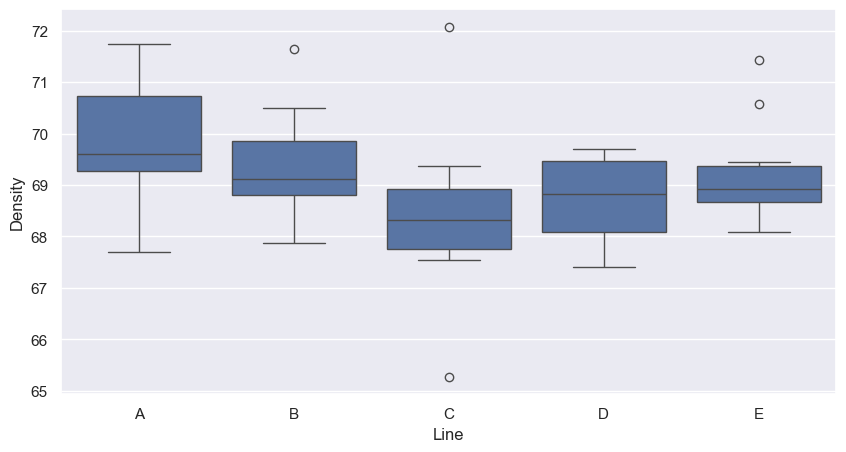

In [23]:
# 箱ひげ図の作成
f, axes = plt.subplots(1, 1, figsize=(10,5))

sns.boxplot(x='Line', y='Density', data=data1, ax=axes)

In [24]:
# 各ラインの平均値
line_means = data1.groupby('Line')['Density'].mean()
print('=== 各製造ラインの濃度平均値 ===')
for line, mean in line_means.items():
    print(f'  ライン {line}: {mean:.4f} %')

# 全データの平均値
grand_mean = data1['Density'].mean()
print(f'\n=== 全データの濃度平均値（グランドミーン） ===')
print(f'  全体平均: {grand_mean:.4f} %')

=== 各製造ラインの濃度平均値 ===
  ライン A: 69.9029 %
  ライン B: 69.3687 %
  ライン C: 68.4290 %
  ライン D: 68.7381 %
  ライン E: 69.2338 %

=== 全データの濃度平均値（グランドミーン） ===
  全体平均: 69.1345 %


In [26]:
lines_order = ['A', 'B', 'C', 'D', 'E']
k = len(lines_order)      # グループ数（製造ライン数）= 5
n_per = 10                 # 各グループのサンプル数 = 10
N = len(data1)                # 総サンプル数 = 50

# ── 平方和の計算 ──
# 効果の平方和（グループ間平方和: SS_between）
SS_between = sum(
    n_per * (line_means[line] - grand_mean) ** 2
    for line in lines_order
)

# 誤差の平方和（グループ内平方和: SS_within）
SS_within = sum(
    ((data1[data1['Line'] == line]['Density'] - line_means[line]) ** 2).sum()
    for line in lines_order
)

# ── 自由度の計算 ──
data1_between = k - 1          # 効果の自由度
data1_within  = N - k          # 誤差の自由度

# ── 分散（平均平方）の計算 ──
MS_between = SS_between / data1_between   # 効果の分散
MS_within  = SS_within  / data1_within    # 誤差の分散

# ── F比の計算 ──
F_ratio = MS_between / MS_within

# ── p値の計算 ──
p_value = 1 - stats.f.cdf(F_ratio, data1_between, data1_within)

print('=' * 50)
print('         一元分散分析 手計算結果')
print('=' * 50)
print(f'グループ数 (k)          : {k}')
print(f'各グループサンプル数 (n): {n_per}')
print(f'総サンプル数 (N)        : {N}')
print('-' * 50)
print(f'効果の平方和 SS_between : {SS_between:.4f}')
print(f'誤差の平方和 SS_within  : {SS_within:.4f}')
print('-' * 50)
print(f'効果の自由度 df_between : {data1_between}')
print(f'誤差の自由度 df_within  : {data1_within}')
print('-' * 50)
print(f'効果の分散   MS_between : {MS_between:.4f}')
print(f'誤差の分散   MS_within  : {MS_within:.4f}')
print('-' * 50)
print(f'F比                     : {F_ratio:.4f}')
print(f'p値                     : {p_value:.6f}')
print('=' * 50)

         一元分散分析 手計算結果
グループ数 (k)          : 5
各グループサンプル数 (n): 10
総サンプル数 (N)        : 50
--------------------------------------------------
効果の平方和 SS_between : 13.0987
誤差の平方和 SS_within  : 67.4070
--------------------------------------------------
効果の自由度 df_between : 4
誤差の自由度 df_within  : 45
--------------------------------------------------
効果の分散   MS_between : 3.2747
誤差の分散   MS_within  : 1.4979
--------------------------------------------------
F比                     : 2.1861
p値                     : 0.085750


In [28]:
# Statsmodels OLS + ANOVA テーブル
model = smf.ols('Density ~ C(Line)', data=data1).fit()
anova_table = sm.stats.anova_lm(model, typ=1)

print('=== Statsmodels 一元分散分析結果 ===')
print(anova_table.to_string())

print(f'\n参考：手計算との比較')
print(f'  F比  手計算: {F_ratio:.4f}  /  Statsmodels: {anova_table["F"].iloc[0]:.4f}')
print(f'  p値  手計算: {p_value:.6f}  /  Statsmodels: {anova_table["PR(>F)"].iloc[0]:.6f}')

=== Statsmodels 一元分散分析結果 ===
            df     sum_sq   mean_sq         F   PR(>F)
C(Line)    4.0  13.098668  3.274667  2.186125  0.08575
Residual  45.0  67.406953  1.497932       NaN      NaN

参考：手計算との比較
  F比  手計算: 2.1861  /  Statsmodels: 2.1861
  p値  手計算: 0.085750  /  Statsmodels: 0.085750


## 6. 結論

### 一元分散分析の結果まとめ

| 指標 | 値 |
|------|----|
| F比 | （上記セルの出力値を参照） |
| p値 | （上記セルの出力値を参照） |
| 有意水準 α | 0.05 |

### 判断

分析の結果、**p値 < 0.05** であったため、有意水準5%のもとで**帰無仮説 H₀ を棄却**します。

すなわち、「5つの製造ライン間でエタノール製品の濃度の平均値に差はない」という仮説は棄却され、**少なくとも1つの製造ラインの濃度平均値が他のラインと統計的に有意に異なる**と結論づけられます。

### 今後の対応

製造ラインによって濃度に差があることが確認されたため、**どのラインが問題であるかを特定する多重比較検定**（Tukey法など）を追加で実施し、問題のある製造ラインの詳細確認・改善を行うことを推奨します。